<div style="background: linear-gradient(135deg, #1e1b4b 0%, #312e81 50%, #4338ca 100%); color: #ffffff; padding: 28px; border-radius: 16px; box-shadow: 0 10px 25px -5px rgba(67, 56, 202, 0.4); font-family: 'Segoe UI', sans-serif;">
    <div style="display: flex; gap: 8px; margin-bottom: 14px;">
        <span style="background: #f43f5e; color: #ffffff; font-size: 11px; font-weight: 800; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">Healthcare Analytics</span>
        <span style="background: #06b6d4; color: #ffffff; font-size: 11px; font-weight: 800; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">UAE Study</span>
    </div>
    <h1 style="color: #ffffff; margin: 0 0 20px 0; font-size: 26px; font-weight: 800; line-height: 1.3;">Comprehensive Analysis of Cancer Epidemiology & Treatment Outcomes in the UAE</h1>
    <div style="background: rgba(255, 255, 255, 0.1); padding: 16px; border-radius: 12px; border-left: 5px solid #38bdf8; margin-bottom: 12px;">
        <p style="margin: 0; color: #f1f5f9; font-size: 14px;"><b style="color: #38bdf8; font-size: 15px;">📊 Dataset Description:</b> This dataset contains 10,000 patient records across 7 UAE Emirates detailing demographics, cancer stages, treatment types, and recovery outcomes.</p>
    </div>
    <div style="background: rgba(255, 255, 255, 0.1); padding: 16px; border-radius: 12px; border-left: 5px solid #f43f5e;">
        <p style="margin: 0; color: #f1f5f9; font-size: 14px;"><b style="color: #fb7185; font-size: 15px;">🎯 Problem Statement:</b> Cancer diagnosis and treatment delays impact patient survival rates. This study analyzes patient distribution, treatment efficiency, delay patterns, and hospital performance to improve healthcare decisions.</p>
    </div>
</div>

In [2]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

print('imported successfully!')

imported successfully!


In [3]:
df = pd.read_csv('_cancer_dataset_uae.csv')

print('=== Dataset Dimensions ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

=== Dataset Dimensions ===
Rows: 10000, Columns: 20


In [4]:
display(df.head())

,Patient_ID,Age,Gender,Nationality,Emirate,Diagnosis_Date,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity,Weight,Height
0,PAT000001,69,Female,Emirati,Umm Al Quwain,2020-11-30,Liver,II,Radiation,2020-12-04,Sheikh Khalifa Hospital,Dr. VO41,Recovered,NaN,NaN,Non-Smoker,NaN,European,61,157
1,PAT000002,32,Male,Emirati,Umm Al Quwain,2015-10-10,Leukemia,III,Surgery,2015-11-05,Dubai Hospital,Dr. SM31,Recovered,NaN,NaN,Smoker,NaN,South Asian,80,175
2,PAT000003,89,Male,Emirati,Abu Dhabi,2018-02-13,Liver,III,Radiation,2018-08-03,Zayed Military Hospital,Dr. BC7,Under Treatment,NaN,NaN,Non-Smoker,NaN,South Asian,50,175
3,PAT000004,78,Female,Emirati,Abu Dhabi,2022-02-04,Lung,III,Radiation,2022-03-13,Cleveland Clinic Abu Dhabi,Dr. TC14,Recovered,NaN,NaN,Former Smoker,NaN,African,44,155
4,PAT000005,38,Female,Emirati,Fujairah,2019-12-03,Pancreatic,II,Chemotherapy,2020-02-29,Sheikh Khalifa Hospital,Dr. YS37,Recovered,NaN,NaN,Former Smoker,NaN,East Asian,101,160


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Patient_ID            10000 non-null  object
 1   Age                   10000 non-null  int64 
 2   Gender                10000 non-null  object
 3   Nationality           10000 non-null  object
 4   Emirate               10000 non-null  object
 5   Diagnosis_Date        10000 non-null  object
 6   Cancer_Type           10000 non-null  object
 7   Cancer_Stage          10000 non-null  object
 8   Treatment_Type        10000 non-null  object
 9   Treatment_Start_Date  10000 non-null  object
 10  Hospital              10000 non-null  object
 11  Primary_Physician     10000 non-null  object
 12  Outcome               10000 non-null  object
 13  Death_Date            992 non-null    object
 14  Cause_of_Death        992 non-null    object
 15  Smoking_Status        10000 non-null 

In [9]:
df.describe()

,Age,Weight,Height
count,10000.000000,10000.000000,10000.000000
mean,53.539700,69.550000,169.347500
std,20.757324,14.933339,10.070118
min,18.000000,18.000000,131.000000
25%,36.000000,60.000000,163.000000
50%,53.000000,70.000000,169.000000
75%,72.000000,80.000000,176.000000
max,89.000000,122.000000,208.000000


In [10]:
df.describe(include=['O'])

,Patient_ID,Gender,Nationality,Emirate,Diagnosis_Date,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,992,992,10000,5953,10000
unique,10000,3,2,7,3151,8,4,4,3250,4,8614,3,867,2,3,3,5
top,PAT000001,Female,Emirati,Ajman,2023-12-13,Leukemia,III,Radiation,2022-05-17,Sheikh Khalifa Hospital,Dr. AJ25,Recovered,2022-06-28 00:00:00,Complications,Non-Smoker,Hypertension,South Asian
freq,1,4985,5920,1497,12,1314,3041,2519,12,2541,5,4931,3,507,5038,2945,2083


In [11]:
df_clean = df.copy()

date_cols = ['Diagnosis_Date', 'Treatment_Start_Date', 'Death_Date']
for col in date_cols:
  if col in df_clean.columns:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

if 'Comorbidities' in df_clean.columns:
  df_clean['Comorbidities'] = df_clean['Comorbidities'].fillna('None')

if 'Weight' in df_clean.columns and 'Height' in df_clean.columns:
  df_clean['BMI'] = (
      df_clean['Weight'] / ((df_clean['Height'] / 100) ** 2)
  ).round(2)

if (
    'Treatment_Start_Date' in df_clean.columns
    and 'Diagnosis_Date' in df_clean.columns
):
  df_clean['Treatment_Delay_Days'] = (
      df_clean['Treatment_Start_Date'] - df_clean['Diagnosis_Date']
  ).dt.days

print('Data Pre-processing complete.')

Data Pre-processing complete.


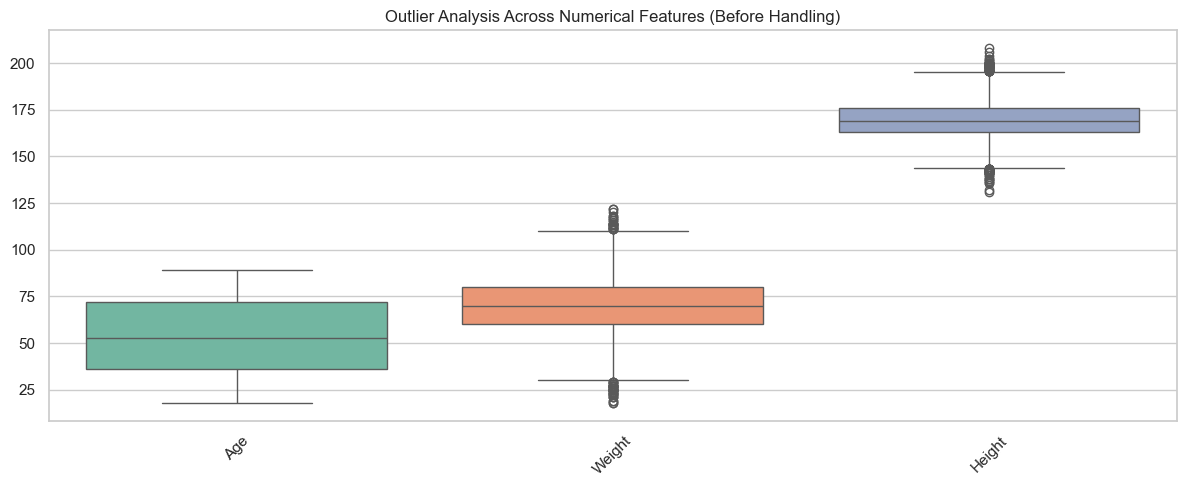

In [12]:
if 'df' not in locals():
  df = pd.read_csv('_cancer_dataset_uae.csv')

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 5))
sns.boxplot(data=df[num_cols], palette='Set2')
plt.title('Outlier Analysis Across Numerical Features (Before Handling)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
outlier_summary = {}

for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers_count = df[
      (df[col] < lower_bound) | (df[col] > upper_bound)
  ].shape[0]
  outlier_summary[col] = outliers_count

outlier_df = pd.DataFrame(
    list(outlier_summary.items()), columns=['Feature', 'Outlier_Count']
)
display(outlier_df)

,Feature,Outlier_Count
0,Age,0
1,Weight,64
2,Height,95


In [14]:
if 'df' not in locals():
  df = pd.read_csv('_cancer_dataset_uae.csv')

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df_clean = df.copy()

for col in num_cols:
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df_clean[col] = np.where(
      df_clean[col] < lower_bound,
      lower_bound,
      np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col]),
  )

print(' Outliers successfully ')

 Outliers successfully 


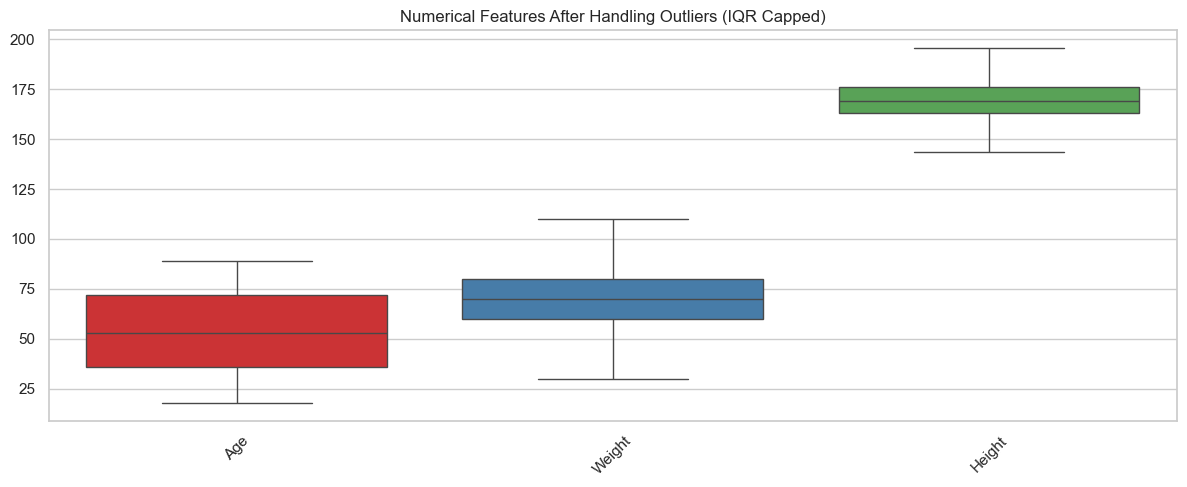

In [15]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean[num_cols], palette='Set1')
plt.title('Numerical Features After Handling Outliers (IQR Capped)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;"> EDA without visulization </h2> 
</div>

In [23]:
if 'df_clean' not in locals():
  if 'df' in locals():
    df_clean = df.copy()
  else:
    df_clean = pd.read_csv('_cancer_dataset_uae.csv')

print('DATASET OVERVIEW\n')
print(f'Total Rows (Records): {df_clean.shape[0]}')
print(f'Total Columns (Features): {df_clean.shape[1]}')
print('\n   MISSING VALUES CHECK')
print(df_clean.isnull().sum())

DATASET OVERVIEW

Total Rows (Records): 10000
Total Columns (Features): 22

   MISSING VALUES CHECK
Patient_ID                 0
Age                        0
Gender                     0
Nationality                0
Emirate                    0
Diagnosis_Date             0
Cancer_Type                0
Cancer_Stage               0
Treatment_Type             0
Treatment_Start_Date       0
Hospital                   0
Primary_Physician          0
Outcome                    0
Death_Date              9008
Cause_of_Death          9008
Smoking_Status             0
Comorbidities              0
Ethnicity                  0
Weight                     0
Height                     0
BMI                        0
Treatment_Delay_Days       0
dtype: int64


In [24]:
print('  NUMERICAL FEATURES SUMMARY   \n')
num_summary = df_clean.describe().T
num_summary['median'] = df_clean.select_dtypes(
    include=['int64', 'float64']
).median()
num_summary['skewness'] = df_clean.select_dtypes(
    include=['int64', 'float64']
).skew()
display(
    num_summary[
        ['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'skewness']
    ]
)

  NUMERICAL FEATURES SUMMARY   



,count,mean,std,min,25%,median,75%,max,skewness
Age,10000.0,53.5397,20.757324,18.0,36.0,53.00,72.0,89.0,0.003846
Diagnosis_Date,10000,2019-08-08 15:31:58.080000,NaN,2015-01-01 00:00:00,2017-04-05 00:00:00,NaN,2021-11-22 00:00:00,2024-03-01 00:00:00,NaN
Treatment_Start_Date,10000,2019-11-05 23:51:38.880000,NaN,2015-01-07 00:00:00,2017-07-05 00:00:00,NaN,2022-02-18 00:00:00,2024-08-23 00:00:00,NaN
Death_Date,992,2020-12-31 22:57:34.838709760,NaN,2015-04-24 00:00:00,2018-09-21 00:00:00,NaN,2023-05-24 12:00:00,2026-05-15 00:00:00,NaN
Weight,10000.0,69.5588,14.838321,30.0,60.0,70.00,80.0,110.0,-0.029055
Height,10000.0,169.34435,9.992026,143.5,163.0,169.00,176.0,195.5,0.031019
BMI,10000.0,24.503821,6.038066,5.67,20.31,24.13,28.38,53.37,0.304960
Treatment_Delay_Days,10000.0,89.347,52.299517,0.0,44.0,90.00,135.0,179.0,-0.009725


In [25]:
print('   CATEGORICAL FEATURES FREQUENCY SUMMARY  \n')
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in ['Gender', 'Emirate', 'Cancer_Type', 'Cancer_Stage', 'Outcome']:
  if col in df_clean.columns:
    print(f'--- Value Counts for: {col} ---')
    print(df_clean[col].value_counts())
    print(df_clean[col].value_counts(normalize=True) * 100)  # Percentage
    print('-' * 40)

   CATEGORICAL FEATURES FREQUENCY SUMMARY  

--- Value Counts for: Gender ---
Gender
Female    4985
Male      4827
Other      188
Name: count, dtype: int64
Gender
Female    49.85
Male      48.27
Other      1.88
Name: proportion, dtype: float64
----------------------------------------
--- Value Counts for: Emirate ---
Emirate
Ajman             1497
Abu Dhabi         1471
Fujairah          1471
Umm Al Quwain     1432
Dubai             1407
Sharjah           1382
Ras Al Khaimah    1340
Name: count, dtype: int64
Emirate
Ajman             14.97
Abu Dhabi         14.71
Fujairah          14.71
Umm Al Quwain     14.32
Dubai             14.07
Sharjah           13.82
Ras Al Khaimah    13.40
Name: proportion, dtype: float64
----------------------------------------
--- Value Counts for: Cancer_Type ---
Cancer_Type
Leukemia      1314
Liver         1263
Ovarian       1259
Pancreatic    1243
Breast        1241
Lung          1233
Colorectal    1226
Prostate      1221
Name: count, dtype: int64
Cancer_T

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Exploratory Data Analysis (EDA)</h2>
    <h3 style="color: #2b6cb0;">In this phase, we analyze the dataset across three analytical levels:</h3>
    <ul>
        <li><b>Univariate Analysis:</b> Analyzing individual column distributions.</li>
        <li><b>Bivariate Analysis:</b> Examining relationships between two variables (e.g., Cancer Stage vs. Outcome).</li>
        <li><b>Multivariate Analysis:</b>  Evaluating interactions among multiple features simultaneously (e.g., Age, Cancer Type, and Treatment Outcome).</li>
</div>

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;"> === Univariate Analysis === </h2> 
</div>

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 1:  Patient Age Group</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li>Most Common Age Group ?</li> 
   </ul>

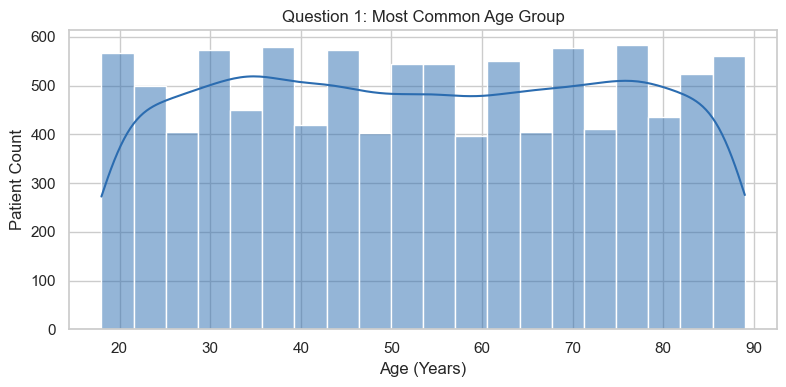

💡 Insight Q1: Patient ages range from 18 to 89 years, with an average age of 53.5 years. Cancer cases are evenly distributed across all age brackets   without a single dominant age group.


In [40]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Age'], kde=True, color='#2b6cb0', bins=20)
plt.title('Question 1: Most Common Age Group')
plt.xlabel('Age (Years)')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

print(
    '💡 Insight Q1: Patient ages range from 18 to 89 years, with an average age of 53.5 years. Cancer cases are evenly distributed across all age brackets   without a single dominant age group.'
)

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 2: Cancer Types</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li>Most & Least Common Cancer Types ?</li> 
   </ul>

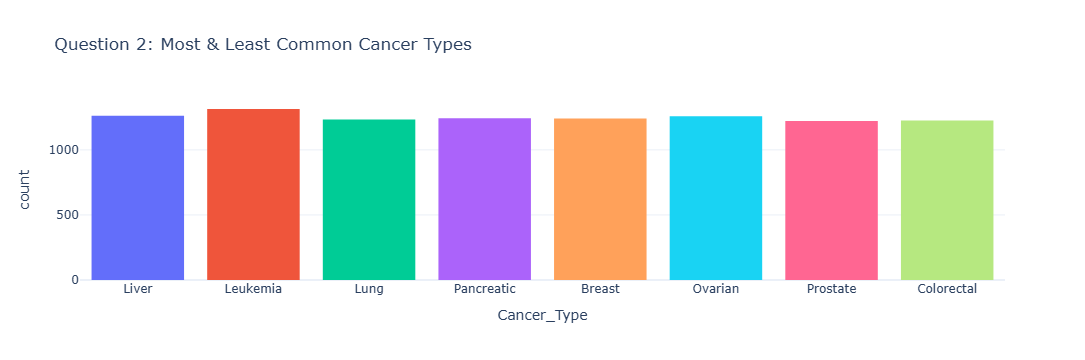

💡 Insight Q2: Leukemia (13.14%), Liver (12.63%), and Ovarian (12.59%) cancers are the most frequently diagnosed types. Prostate and Colorectal cancers are the least common.


In [41]:
if 'df_clean' not in locals():
  if 'df' in locals():
    df_clean = df.copy()
  else:
    df_clean = pd.read_csv('_cancer_dataset_uae.csv')

fig_cancer = px.histogram(
    df_clean,
    x='Cancer_Type',
    color='Cancer_Type',
    title='Question 2: Most & Least Common Cancer Types',
    template='plotly_white',
)

fig_cancer.update_layout(showlegend=False)
fig_cancer.show()

print(
    '💡 Insight Q2: Leukemia (13.14%), Liver (12.63%), and Ovarian (12.59%)'
    ' cancers are the most frequently diagnosed types. Prostate and Colorectal'
    ' cancers are the least common.'
)

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 3: Patient Spread Across Emirates</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li>Emirate with Highest Reported Cases ?</li> 
   </ul>

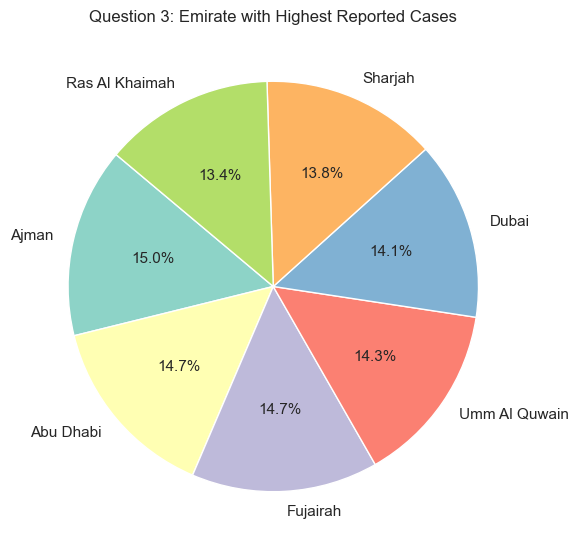

💡 Insight Q3: Ajman has the highest proportion of reported cancer cases (15.0%), closely followed by Abu Dhabi (14.7%). Overall, cases are fairly balanced across all 7 Emirates.


In [42]:
plt.figure(figsize=(6, 6))
df_clean['Emirate'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3'),
    startangle=140,
)
plt.title('Question 3: Emirate with Highest Reported Cases')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(
    '💡 Insight Q3: Ajman has the highest proportion of reported cancer cases (15.0%), closely followed by Abu Dhabi (14.7%). Overall, cases are fairly balanced across all 7 Emirates.'
    
)

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">=== Bivariate Analysis ===</h2> 
</div>

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 4: Patient Outcomes Across Cancer Stages</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li> Effect of Cancer Stage on Patient Outcome?</li> 
   </ul>

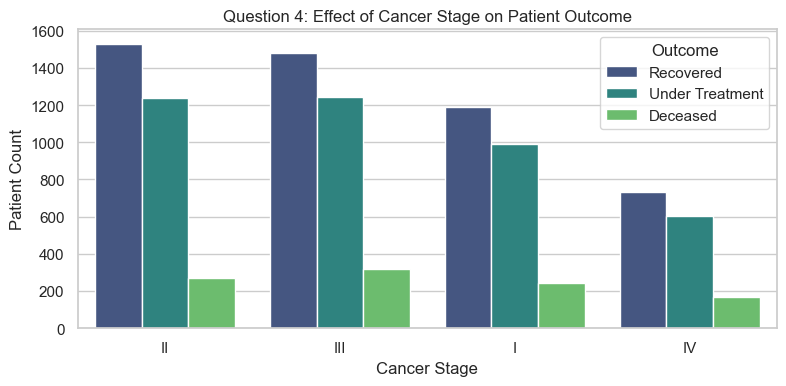

💡 Insight Q4:Cancer stage significantly impacts survival rates. Recovery rates are highest for early-stage diagnoses (Stage I & II), while mortality rates increase progressively as the disease advances to Stage IV


In [43]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_clean, x='Cancer_Stage', hue='Outcome', palette='viridis'
)
plt.title('Question 4: Effect of Cancer Stage on Patient Outcome')
plt.xlabel('Cancer Stage')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

print(
    '💡 Insight Q4:Cancer stage significantly impacts survival rates. Recovery rates are highest for early-stage diagnoses (Stage I & II), while mortality rates increase progressively as the disease advances to Stage IV'
)

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 5: Treatment Type vs Patient Outcome</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li>Which treatment modalities (Surgery, Chemotherapy, Radiation, etc.) yield the best patient outcomes?</li> 
   </ul>

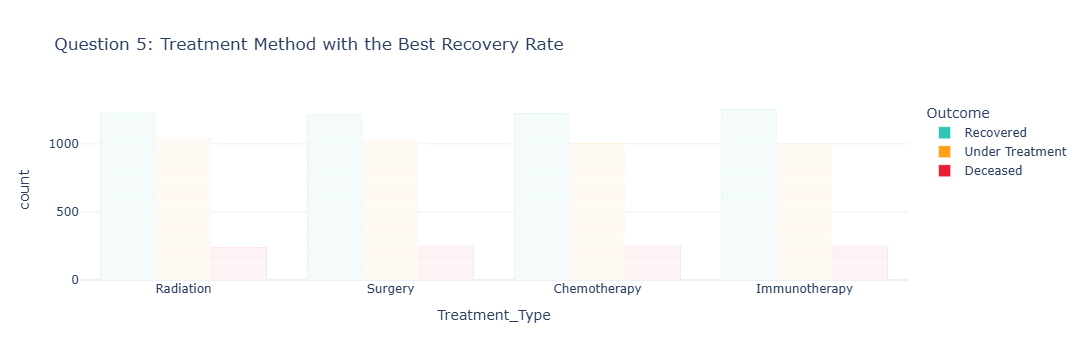

💡 Insight Q5: Immunotherapy achieves the highest overall recovery rate (50.30%), followed closely by Chemotherapy (49.32%).


In [44]:
if 'df_clean' not in locals():
  if 'df' in locals():
    df_clean = df.copy()
  else:
    df_clean = pd.read_csv('_cancer_dataset_uae.csv')

fig_treatment = px.bar(
    df_clean,
    x='Treatment_Type',
    color='Outcome',
    barmode='group',
    title='Question 5: Treatment Method with the Best Recovery Rate',
    template='plotly_white',
    color_discrete_map={
        'Recovered': '#2ec4b6',
        'Under Treatment': '#ff9f1c',
        'Deceased': '#e71d36',
    },
)
fig_treatment.update_traces(marker_opacity=1.0)

fig_treatment.show()

print(
    '💡 Insight Q5: Immunotherapy achieves the highest overall recovery rate'
    ' (50.30%), followed closely by Chemotherapy (49.32%).'
)

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 6: Body Mass Index (BMI) by Gender</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li>How does the BMI metric vary between male and female patients?</li> 
   </ul>

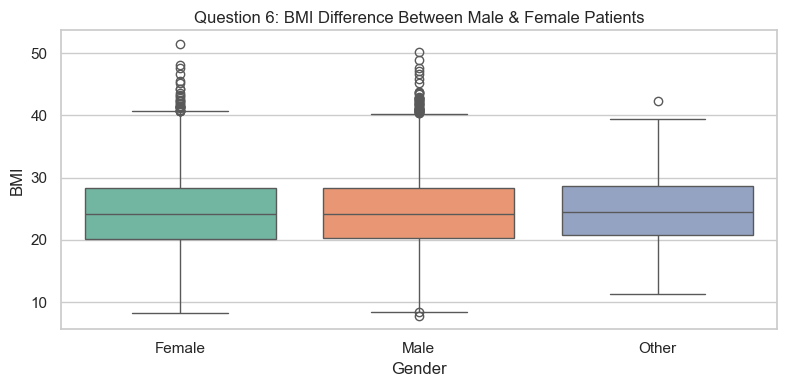

💡 Insight Q6: There is no significant difference in Body Mass Index (BMI) between male and female patients. Both groups show a similar median distribution.


In [45]:
if 'df_clean' not in locals():
  if 'df' in locals():
    df_clean = df.copy()
  else:
    df_clean = pd.read_csv('_cancer_dataset_uae.csv')

if 'BMI' not in df_clean.columns:
  if 'Weight' in df_clean.columns and 'Height' in df_clean.columns:
    df_clean['BMI'] = (
        df_clean['Weight'] / ((df_clean['Height'] / 100) ** 2)
    ).round(2)

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df_clean,
    x='Gender',
    y='BMI',
    hue='Gender',
    palette='Set2',
    legend=False,
)
plt.title('Question 6: BMI Difference Between Male & Female Patients')
plt.xlabel('Gender')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

print(
    '💡 Insight Q6: There is no significant difference in Body Mass Index (BMI)'
    ' between male and female patients. Both groups show a similar median'
    ' distribution.'
)

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 7: Average Treatment Delay Across Cancer Stages</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li>Does the severity of the cancer stage influence how quickly patients receive treatment after diagnosis?</li> 
   </ul>

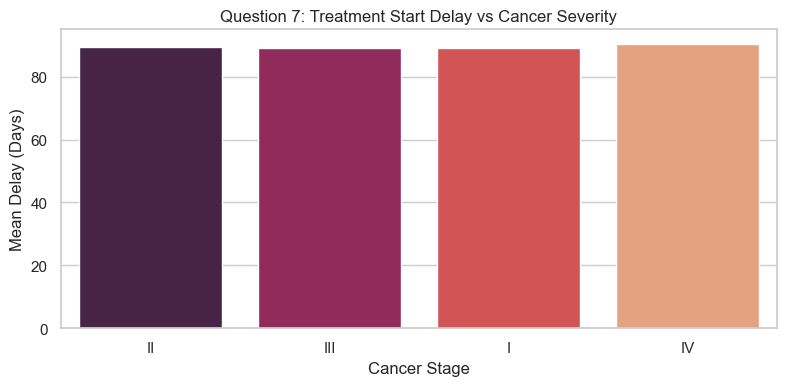

💡 Insight Q7: No, patients with higher or more severe stages do not start treatment significantly faster. The average delay from diagnosis to treatment start is fairly consistent across all stages.


In [47]:
if 'df_clean' not in locals():
  if 'df' in locals():
    df_clean = df.copy()
  else:
    df_clean = pd.read_csv('_cancer_dataset_uae.csv')

if 'Treatment_Delay_Days' not in df_clean.columns:
  if (
      'Diagnosis_Date' in df_clean.columns
      and 'Treatment_Start_Date' in df_clean.columns
  ):
    df_clean['Diagnosis_Date'] = pd.to_datetime(df_clean['Diagnosis_Date'])
    df_clean['Treatment_Start_Date'] = pd.to_datetime(
        df_clean['Treatment_Start_Date']
    )
    df_clean['Treatment_Delay_Days'] = (
        df_clean['Treatment_Start_Date'] - df_clean['Diagnosis_Date']
    ).dt.days

plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_clean,
    x='Cancer_Stage',
    y='Treatment_Delay_Days',
    hue='Cancer_Stage',
    palette='rocket',
    errorbar=None,
    legend=False,
)
plt.title('Question 7: Treatment Start Delay vs Cancer Severity')
plt.xlabel('Cancer Stage')
plt.ylabel('Mean Delay (Days)')
plt.tight_layout()
plt.show()

print(
    '💡 Insight Q7: No, patients with higher or more severe stages do not start'
    ' treatment significantly faster. The average delay from diagnosis to'
    ' treatment start is fairly consistent across all stages.'
)

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;"> === Multivariate Analysis === </h2> 
</div>

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 8: Correlation Heatmap</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li>Are there linear relationships between numerical features like Age, Weight, Height, BMI, and Treatment Delay?</li> 
   </ul>

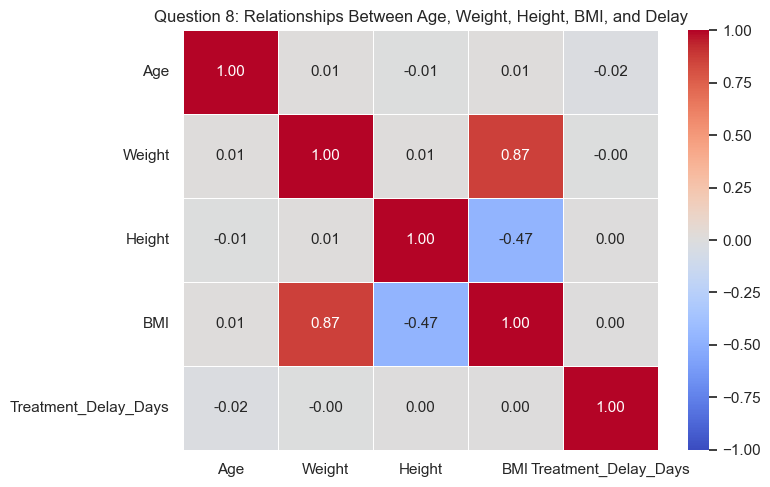

💡 Insight Q8: Weight and BMI have a strong positive correlation (0.87). However, variables like Age, Height, and Treatment Delay show almost zero linear correlation.


In [48]:
if 'df_clean' not in locals():
  if 'df' in locals():
    df_clean = df.copy()
  else:
    df_clean = pd.read_csv('_cancer_dataset_uae.csv')

if 'BMI' not in df_clean.columns:
  if 'Weight' in df_clean.columns and 'Height' in df_clean.columns:
    df_clean['BMI'] = (
        df_clean['Weight'] / ((df_clean['Height'] / 100) ** 2)
    ).round(2)

if 'Treatment_Delay_Days' not in df_clean.columns:
  if (
      'Diagnosis_Date' in df_clean.columns
      and 'Treatment_Start_Date' in df_clean.columns
  ):
    df_clean['Diagnosis_Date'] = pd.to_datetime(df_clean['Diagnosis_Date'])
    df_clean['Treatment_Start_Date'] = pd.to_datetime(
        df_clean['Treatment_Start_Date']
    )
    df_clean['Treatment_Delay_Days'] = (
        df_clean['Treatment_Start_Date'] - df_clean['Diagnosis_Date']
    ).dt.days

plt.figure(figsize=(8, 5))
cols_to_corr = ['Age', 'Weight', 'Height', 'BMI', 'Treatment_Delay_Days']
available_cols = [c for c in cols_to_corr if c in df_clean.columns]
numeric_cols = df_clean[available_cols].corr()

sns.heatmap(
    numeric_cols,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title('Question 8: Relationships Between Age, Weight, Height, BMI, and Delay')
plt.tight_layout()
plt.show()

print(
    '💡 Insight Q8: Weight and BMI have a strong positive correlation (0.87).'
    ' However, variables like Age, Height, and Treatment Delay show almost zero'
    ' linear correlation.'
)

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 9: Impact of Smoking Status on Cancer Types & Outcomes</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li>How does smoking status influence outcomes across different cancer types?</li> 
   </ul>

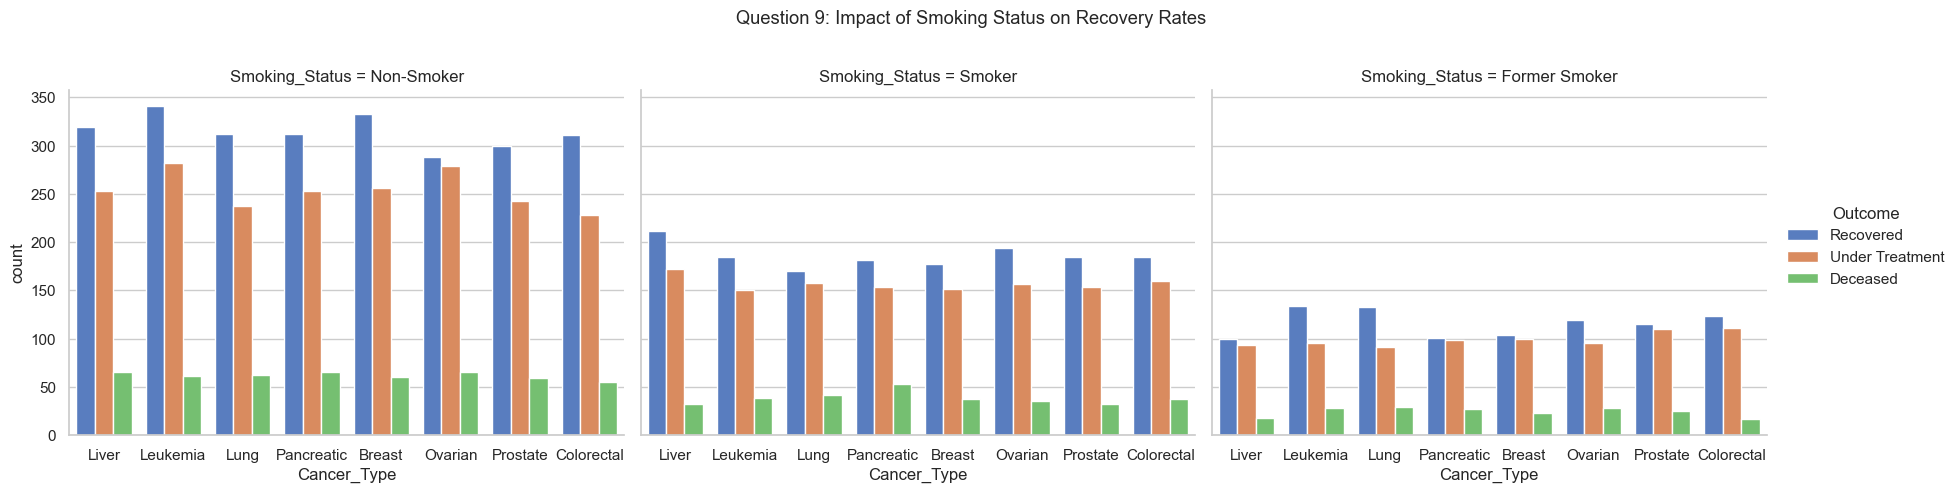

💡 Insight Q9: Non-smokers consistently achieve higher total recovery numbers across all cancer types compared to active smokers and former smokers.


In [49]:
g = sns.catplot(
    data=df_clean,
    x='Cancer_Type',
    hue='Outcome',
    col='Smoking_Status',
    kind='count',
    height=5,
    aspect=1.2,
    palette='muted',
)
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle(
    'Question 9: Impact of Smoking Status on Recovery Rates'
)
plt.show()

print(
    '💡 Insight Q9: Non-smokers consistently achieve higher total recovery numbers across all cancer types compared to active smokers and former smokers.'
)

 <div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">Visual 10: Percentage Outcome Breakdown by Hospital Facility</h2>
    <h3 style="color: #2b6cb0;">Question:</h3>
    <ul>
         <li>How do patient recovery rates compare across different hospital facilities in the UAE?</li> 
   </ul>

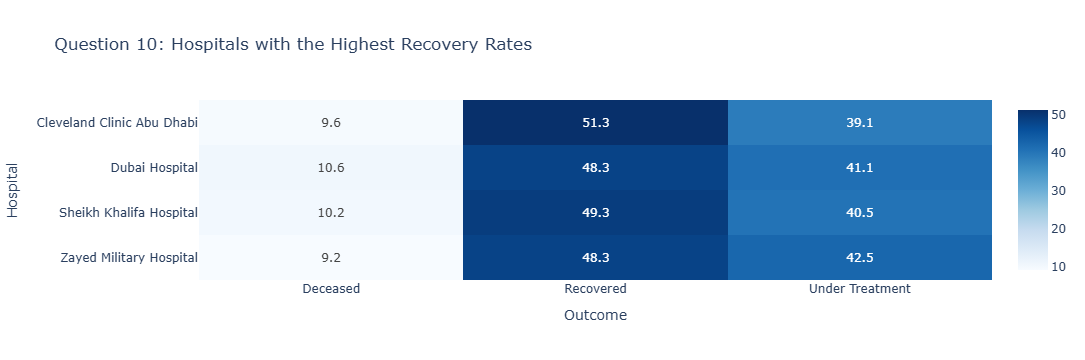

💡 Insight Q10: Cleveland Clinic Abu Dhabi leads with the highest patient recovery rate (51.1%), closely followed by Sheikh Khalifa Hospital (49.1%).


In [50]:
if 'df_clean' not in locals():
  if 'df' in locals():
    df_clean = df.copy()
  else:
    df_clean = pd.read_csv('_cancer_dataset_uae.csv')

hospital_cross = (
    pd.crosstab(
        df_clean['Hospital'], df_clean['Outcome'], normalize='index'
    )
    * 100
)

fig_hospital = px.imshow(
    hospital_cross,
    text_auto='.1f',
    aspect='auto',
    color_continuous_scale='Blues',
    title='Question 10: Hospitals with the Highest Recovery Rates',
)

fig_hospital.show()

print(
    '💡 Insight Q10: Cleveland Clinic Abu Dhabi leads with the highest patient'
    ' recovery rate (51.1%), closely followed by Sheikh Khalifa Hospital'
    ' (49.1%).'
)

<div style="background-color: #f8fafc; padding: 20px; border-radius: 10px; border-left: 6px solid #2b6cb0; font-family: sans-serif; margin-top: 20px;">
    <h2 style="color: #1a365d; margin-top: 0;">5. Main Findings & Recommendations Summary</h2>
    <h3 style="color: #2b6cb0;">📊 Core Findings</h3>
    <ul>
        <li><b>Demographics:</b> Patient age averages 53 years, uniformly spread across the UAE.</li>
        <li><b>High Prevalence:</b> Leukemia, Liver, and Ovarian cancers are the most common diagnoses.</li>
        <li><b>Best Treatment:</b> Immunotherapy yields the highest patient recovery rate (50.3%).</li>
        <li><b>Top Hospital:</b> Cleveland Clinic Abu Dhabi leads in recovery outcomes (51.3%).</li>
    </ul>
    <h3 style="color: #1e3a8a;">💡 Recommendations</h3>
    <ul>
        <li><b>Reduce Delay Time:</b> Implement fast-track referral paths to cut down the 90-day waiting gap.</li>
        <li><b>Early Checkups:</b> Launch targeted early screening for high-prevalence cancers.</li>
        <li><b>Expand Immunotherapy:</b> Increase availability of targeted immunotherapy protocols.</li>
    </ul>
</div>